In [1]:
from langchain_community.document_loaders import DirectoryLoader, PyMuPDFLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch
from langgraph.graph import StateGraph, END
from typing import TypedDict
from dotenv import load_dotenv
import os

load_dotenv()

C:\Users\praju\AppData\Local\Temp\ipykernel_23424\3059542475.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import DirectoryLoader, PyMuPDFLoader


True

### Building Components

In [2]:
def doc_loader(path):
    try:
        loader = DirectoryLoader(path,
                                glob="**/*.pdf",
                                loader_cls=PyMuPDFLoader,
                                show_progress=True)
        documents = loader.load()
        print(f"Loaded {len(documents)} documents from {path}")
        return documents
    except Exception as e:
        print(f"Error loading documents from {path}: {e}")
        return None

def text_splitter(documents):
    print("Splitting documents into chunks...")
    try:
        if not documents:
            raise ValueError("No documents to split")
        splitter = RecursiveCharacterTextSplitter(chunk_size=1000, 
                                              chunk_overlap=150,
                                              length_function=len,
                                              separators=["\n\n", "\n", " ", ""])
        chunks = splitter.split_documents(documents)
        print(f"""Split into {len(chunks)} chunks
            Document splitting complete""")
        return chunks
    except Exception as e:
        print(f"Error splitting documents: {e}")
        return None

def create_vector(chunks):
    print('Loading embedding model...')
    embedding = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2"
        )
    print('Creating vector store...')
    vector_store = Chroma.from_documents(chunks, 
                                         embedding, 
                                         collection_name="pdf_docs")
    print('Vector store created successfully')
    return vector_store

def llm_model():
    print('Loading LLM model...')
    llm = ChatOpenAI(
        model="openai/gpt-oss-120b:free", 
        api_key=os.getenv("OPENROUTER_API_KEY"),
        base_url="https://openrouter.ai/api/v1")
    return llm

def get_web_search_tool():
    search_tool = TavilySearch(
        max_results=3
    )
    return search_tool

In [3]:
documents = doc_loader("../data")
chunks = text_splitter(documents)
vector_db = create_vector(chunks)

100%|██████████| 3/3 [00:02<00:00,  1.49it/s]


Loaded 781 documents from ../data
Splitting documents into chunks...
Split into 1573 chunks
            Document splitting complete
Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Creating vector store...
Vector store created successfully


### using the above components to build Agentic RAG pipeline

In [4]:
# defining graph state
class agentstate(TypedDict):
    question:str
    rewritten_query:str
    documents:list
    web_result:str
    answer:str

### Re-writing the user query  

In [5]:
def rewrite(state):
    print("Rewriting user query...")
    query = state["question"]
    llm = llm_model()
    prompt = f"""
    You are a query rewriting assistant.

    Rewrite the query only if it improves retrieval quality.

    Rules:
    - Preserve meaning
    - Do not add information
    - Return the original query if already clear

    Query:
    {query}
    """
    rewritten_query = llm.invoke(prompt)
    print(f"After rewriting the user query: {rewritten_query.content}")
    return {
        "rewritten_query":rewritten_query.content
    }


### Retrival Block

In [6]:
def retriever(state):
    query = state["rewritten_query"]
    retriever_db = vector_db.as_retriever(
        search_kwargs={"k":3}
    )
    r_docs = retriever_db.invoke(query) 
    return {
        "documents":r_docs
    }

### Grade Retrived documents


In [7]:
def search_web(state):
    print("Using the web-search tool...")
    query = state["rewritten_query"]
    search_tool = get_web_search_tool()
    results = search_tool.invoke(query)

    return {
        "web_result":results
    }

def grade_docuemnts(state):
    docs = state["documents"]
    query = state["rewritten_query"]

    context = "\n\n".join(
        [doc.page_content 
        for doc in docs] 
    )

    prompt = f"""
                Determine if the retrieved documents
                contain information useful for answering.

                Question:
                {query}

                Documents:
                {context}

                Answer only:
                yes
                or
                no
    """

    llm = llm_model()
    result = llm.invoke(prompt)

    if "yes" in result.content.strip():
        return "generate"
    return "web_search"

In [8]:
def generator(state):
    print("Generating the Answers...")
    query = state["question"]
    docs = state.get("documents",[])
    web_result = state.get("web_result","")

    if docs:
        context = "\n\n".join(
            [doc.page_content for doc in docs]
        )
    else:
        context = web_result

    prompt = f"""
Answer the following using the provided context

question:{query}

context:{context}
"""
    llm = llm_model()
    response = llm.invoke(prompt)

    return {
        "answer":response.content
    }

In [9]:
workflow = StateGraph(agentstate)

workflow.add_node(
    "rewrite",
    rewrite
)

workflow.add_node(
    "retriever",
    retriever
)

workflow.add_node(
    "web_search",
    search_web
)

workflow.add_node(
    "generate",
    generator
)

In [10]:
workflow.set_entry_point("rewrite")

workflow.add_edge(
    "rewrite",
    "retriever"
)

workflow.add_conditional_edges(
    "retriever",
    grade_docuemnts,
    {
        "generate":"generate",
        "web_search":"web_search"
    }
)

workflow.add_edge(
    "web_search",
    "generate"
)

workflow.add_edge(
    "generate",
    END
)

graph = workflow.compile()

In [13]:
while True:
    user_query = input("Enter your query:")
    if user_query == "exit":
        break
    
    response = graph.invoke(
        {
            "question":user_query
        }
    )
    print(response["answer"])

Rewriting user query...
Loading LLM model...
After rewriting the user query: fight between Sung Jin-Woo and Beru
Loading LLM model...
Using the web-search tool...
Generating the Answers...
Loading LLM model...
In the excerpt there is **no fight between Sung Jin‑woo and Beru**.  

Jin‑woo actually *refrains* from summoning Beru as a combatant because the other hunters are terrified of the beast’s past deeds, and he worries about traumatizing Haein. He instead calls on Igris, his strongest shadow soldier, to handle the battle.  

Beru only appears later, expressing loyalty (“My king!”) and offering advice, but no confrontation between Jin‑woo and Beru occurs in this scene.


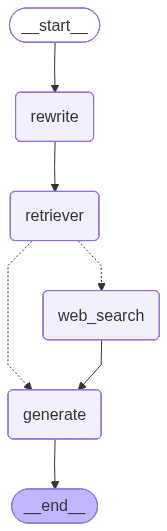

In [12]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)